In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/portfolio_data.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   object 
 1   AMZN    1520 non-null   float64
 2   DPZ     1520 non-null   float64
 3   BTC     1520 non-null   float64
 4   NFLX    1520 non-null   float64
dtypes: float64(4), object(1)
memory usage: 59.5+ KB


,AMZN,DPZ,BTC,NFLX
count,1520.000000,1520.000000,1520.000000,1520.000000
mean,821.541810,146.771695,2421.465669,147.668273
std,518.442653,72.192287,3310.894199,107.641486
min,248.229996,51.190983,69.660004,29.464285
25%,364.360001,84.993593,340.904999,62.851071
50%,686.459992,127.168053,625.304993,104.000000
75%,1121.287536,202.454994,3874.912415,192.207496
max,2039.510010,298.635986,18972.320310,418.970001


In [9]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

df_returns = df.pct_change().dropna()
cols = ['AMZN','DPZ','BTC','NFLX']  # match your notebook
rets = df_returns[cols].dropna().values  # raw returns (unscaled)
names = cols

rows = []
for i, name in enumerate(names):
    s = df_returns[name].dropna().values
    lag1 = pd.Series(s).autocorr(lag=1)
    pct_near_zero = np.mean(np.isclose(s, 0, atol=1e-4))
    sign_acc = np.mean(np.sign(s[1:]) == np.sign(s[:-1]))           # naive directional accuracy
    mae_naive = np.mean(np.abs(s[1:] - s[:-1]))                    # naive MAE
    rmse_naive = np.sqrt(np.mean((s[1:] - s[:-1])**2))             # naive RMSE
    n_outliers = np.sum(np.abs(s) > 2 * np.std(s))                 # big moves count
    rows.append({
        "asset": name,
        "std": np.std(s, ddof=0),
        "lag1_autocorr": lag1,
        "sign_accuracy_naive": sign_acc,
        "MAE_naive": mae_naive,
        "RMSE_naive": rmse_naive,
        "pct_near_zero": pct_near_zero,
        "n_outliers(>|2σ|)": int(n_outliers),
        "skew": float(skew(s)),
        "kurtosis": float(kurtosis(s))
    })

pd.DataFrame(rows).set_index("asset").round(4)

,std,lag1_autocorr,sign_accuracy_naive,MAE_naive,RMSE_naive,pct_near_zero,n_outliers(>|2σ|),skew,kurtosis
asset,,,,,,,,,
AMZN,0.0190,0.0066,0.5053,0.0184,0.0268,0.0053,69,0.5173,9.2553
DPZ,0.0158,-0.0367,0.4816,0.0162,0.0228,0.0059,66,0.1394,8.8130
BTC,0.1046,-0.0577,0.4960,0.0542,0.1521,0.0013,15,22.1567,704.6603
NFLX,0.0267,0.0189,0.4651,0.0266,0.0374,0.0033,73,0.6300,9.3279


In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.set_index("Date")
df.head()
df.tail()

,AMZN,DPZ,BTC,NFLX
Date,,,,
2019-05-08,1917.770020,283.149994,6171.959961,364.369995
2019-05-09,1899.869995,282.160004,6358.290039,362.750000
2019-05-10,1889.979980,278.369995,7191.359863,361.040009
2019-05-13,1822.680054,273.880005,7980.129883,345.260010
2019-05-14,1840.119995,272.859985,8183.830078,345.609985


<function matplotlib.pyplot.show(close=None, block=None)>

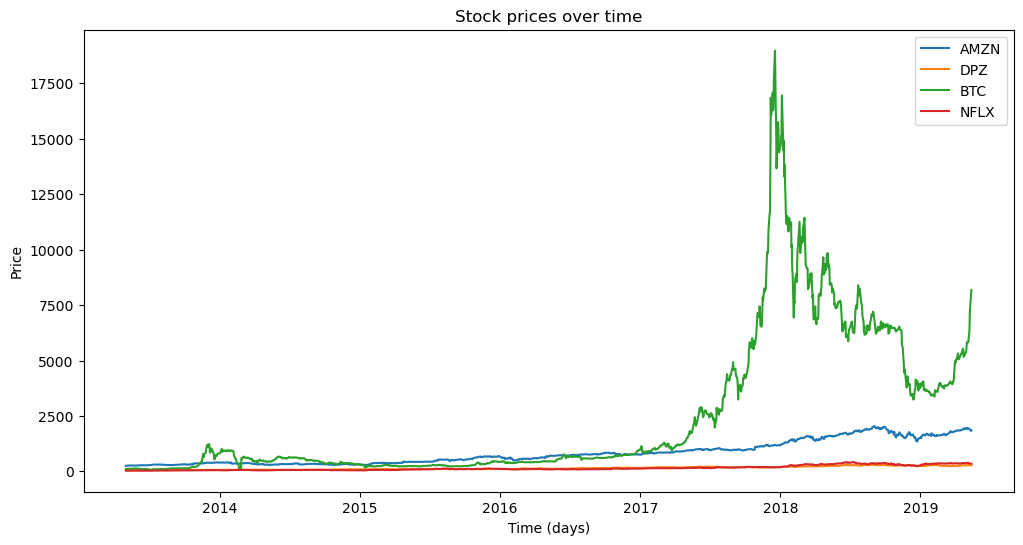

In [5]:
plt.figure(figsize=(12,6))

for col in df.columns:
    plt.plot(df.index, df[col], label=col)

plt.legend()
plt.title("Stock prices over time")
plt.xlabel("Time (days)")
plt.ylabel("Price")
plt.show

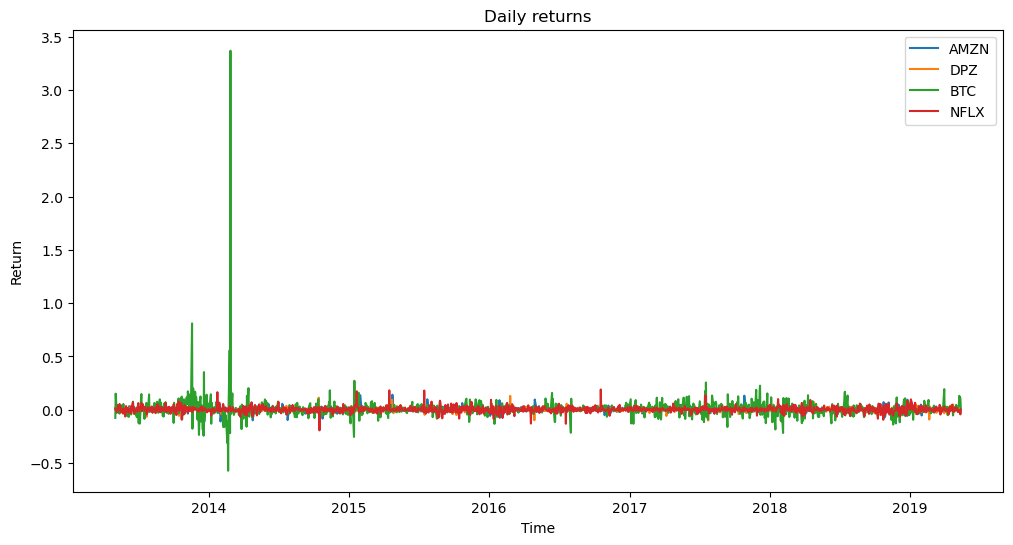

In [6]:
returns = df.pct_change().dropna()
plt.figure(figsize=(12,6))
for col in returns.columns:
    plt.plot(returns.index, returns[col], label=col)
plt.legend()
plt.title("Daily returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

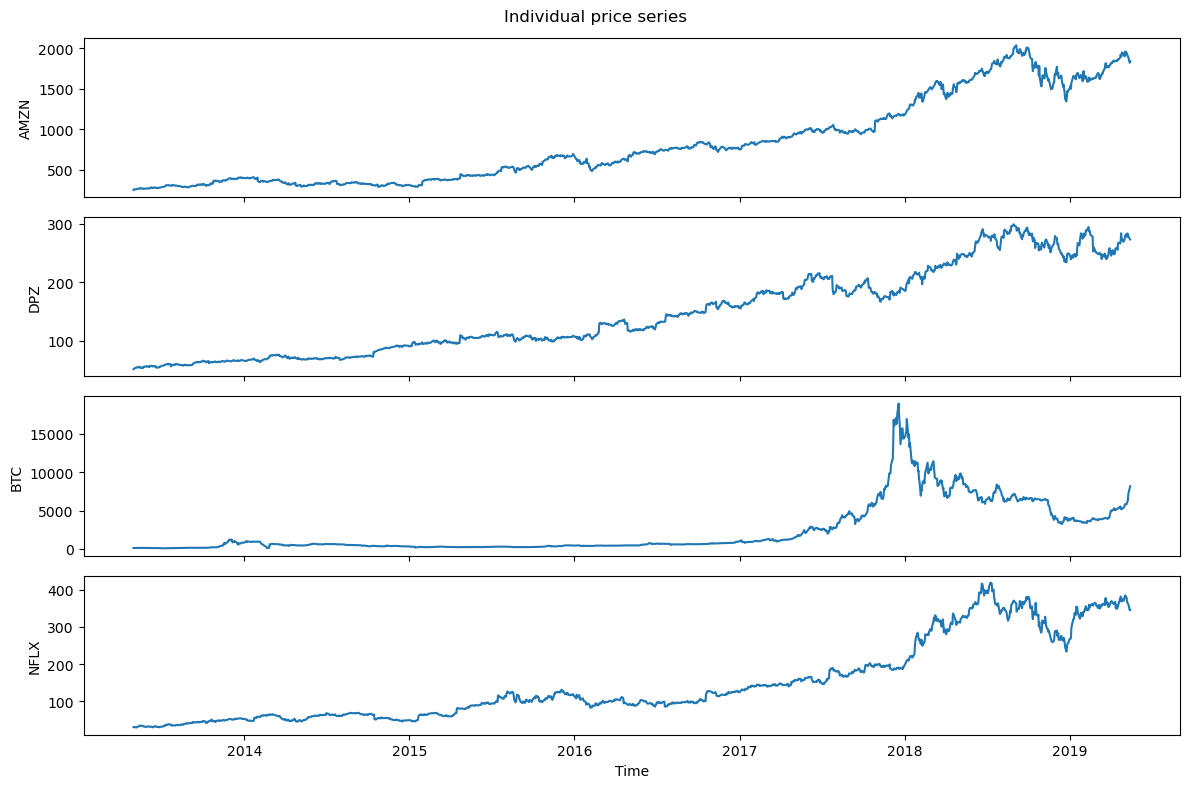

In [7]:
fig, axes = plt.subplots(nrows=len(df.columns), ncols=1, sharex=True, figsize=(12,8))
for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col])
    ax.set_ylabel(col)
fig.suptitle("Individual price series")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

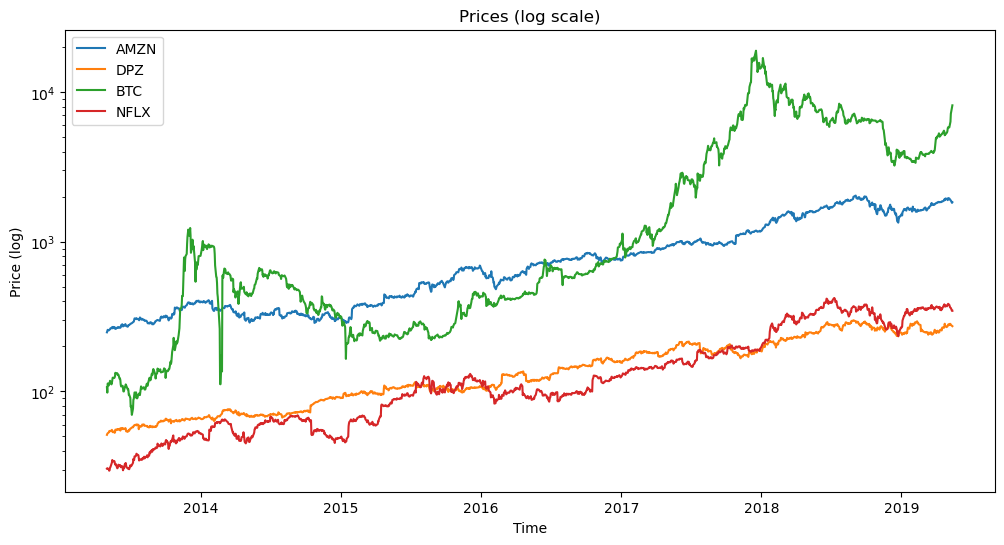

In [8]:
plt.figure(figsize=(12,6))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)
plt.yscale("log")
plt.legend()
plt.title("Prices (log scale)")
plt.xlabel("Time")
plt.ylabel("Price (log)")
plt.show()